<a href="https://colab.research.google.com/github/Pranali-25/LABS/blob/main/Recurrent_neural_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Recurrent neural network**

A recurrent neural network (RNN) is a deep learning model that is trained to process and convert a sequential data input into a specific sequential data output. Sequential data is data—such as words, sentences, or time-series data—where sequential components interrelate based on complex semantics and syntax rules. An RNN is a software system that consists of many interconnected components mimicking how humans perform sequential data conversions, such as translating text from one language to another. RNNs are largely being replaced by transformer-based artificial intelligence (AI) and large language models (LLM), which are much more efficient in sequential data processing.

# **1. Importing the libraries**
Import the necessary libraries such as torch and matplotlib.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Transform to normalize the data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


# **Load the Dataset**
Loading and downloading the MNIST dataset.

In [ ]:
# Load the MNIST dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9912422/9912422 [00:00<00:00, 10536190.08it/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28881/28881 [00:00<00:00, 2261597.66it/s]

Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw



Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1648877/1648877 [00:00<00:00, 13866143.10it/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4542/4542 [00:00<00:00, 7653888.62it/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



# **2.Visualizing the data**
Visualizing some samples from the dataset.


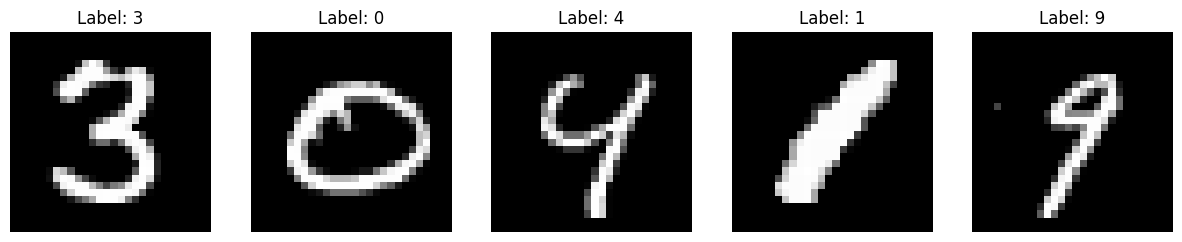

In [ ]:
# Function to visualize some samples from the dataset
def visualize_samples(loader, num_samples=5):
    dataiter = iter(loader)
    images, labels = next(dataiter) # Use next(dataiter) instead of dataiter.next()

    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
    for i in range(num_samples):
        image = images[i].numpy().squeeze()
        axes[i].imshow(image, cmap='gray')
        axes[i].set_title(f'Label: {labels[i].item()}')
        axes[i].axis('off')

    plt.show()

# Visualize some samples from the train loader
visualize_samples(train_loader, num_samples=5)

class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super(SimpleRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.rnn(x, h0)
        out = out[:, -1, :]  # Take the last output of the sequence
        out = self.fc(out)
        return out

# **3.Training the model**

Train the model by using epoch.


In [ ]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

input_size = 28  # Each row of the image
hidden_size = 128
output_size = 10  # 10 classes for 10 digits
num_layers = 1

net = SimpleRNN(input_size, hidden_size, output_size, num_layers).to(device)
print(net)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)
print(criterion)
print(optimizer)

num_epochs = 10

for epoch in range(num_epochs):
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(train_loader):
        # Reshape the input tensor
        inputs = inputs.view(-1, 28, 28).to(device)  # Reshape to (batch_size, sequence_length, input_size)
        labels = labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = net(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 100 == 99:
            print(f'Epoch {epoch + 1}, Batch {i + 1}, Loss: {running_loss / 100:.3f}')
            running_loss = 0.0

print('Finished Training')

cpu
SimpleRNN(
  (rnn): RNN(28, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=10, bias=True)
)
CrossEntropyLoss()
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Epoch 1, Batch 100, Loss: 1.804
Epoch 1, Batch 200, Loss: 1.396
Epoch 1, Batch 300, Loss: 1.259
Epoch 1, Batch 400, Loss: 1.209
Epoch 1, Batch 500, Loss: 1.035
Epoch 1, Batch 600, Loss: 0.897
Epoch 1, Batch 700, Loss: 0.834
Epoch 1, Batch 800, Loss: 0.734
Epoch 1, Batch 900, Loss: 0.700
Epoch 1, Batch 1000, Loss: 0.589
Epoch 1, Batch 1100, Loss: 0.624
Epoch 1, Batch 1200, Loss: 0.543
Epoch 1, Batch 1300, Loss: 0.510
Epoch 1, Batch 1400, Loss: 0.453
Epoch 1, Batch 1500, Loss: 0.474
Epoch 1, Batch 1600, Loss: 0.408
Epoch 1, Batch 1700, Loss: 0.437
Epoch 1, Batch 1800, Loss: 0.396
Epoch 2, Batch 100, Loss: 0.360
Epoch 2, Batch 200, Loss: 

# **4.Evaluating the model**

Evaluating the samples from dataset.

In [ ]:
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.view(-1, 28, 28).to(device)  # Reshape to (batch_size, sequence_length, input_size)
        labels = labels.to(device)
        outputs = net(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the test data: {100 * correct / total:.2f}%')

Accuracy of the network on the test data: 95.11%


# **Conclusion**

This code shows how to adapt an RNN for image classification tasks by reshaping image data into a sequence format by loading the MNIST data using PyTorch’s DataLoader.Defining a SimpleRNN model with an RNN layer followed by a fully connected layer.Training the model using Cross-Entropy Loss and Adam optimizer for 10 epochs and lastly evaluating the dataset.